In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

from src.config import PROCESSED_DATA_DIR, MODELS_DIR, CHURN_WINDOW_DAYS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
model = joblib.load(MODELS_DIR / "churn_model.pkl")
feature_columns = joblib.load(MODELS_DIR / "feature_columns.pkl")
df = pd.read_parquet(PROCESSED_DATA_DIR / "customer_predictions.parquet")

print(f"Loaded model, {len(feature_columns)} features, {len(df):,} customers with predictions")

Loaded model, 21 features, 5,878 customers with predictions


## Project Summary

**Question:** Which customers are at risk of churning, and how should
a retention campaign be targeted to maximize business value?

**Churn:** No purchase within 75 days of a customer's last order —
derived empirically from this customer base's typical reorder gaps (75th–80th
percentile of gaps between consecutive orders).

**Dataset:** UCI Online Retail II — real transactions from a UK-based gift/
wholesale retailer, Dec 2009–Dec 2011, 5,878 customers after cleaning.

**Model:** XGBoost classifier, selected after comparing against Logistic
Regression and Random Forest baselines.

In [4]:
from sklearn.model_selection import train_test_split

TOP_COUNTRIES = ["United Kingdom", "Germany", "France", "Spain", "Belgium"]

df["country_grouped"] = df["country"].where(
    df["country"].isin(TOP_COUNTRIES), other="Other"
)

df_encoded = pd.get_dummies(df, columns=["country_grouped"], drop_first=True)

# align to the exact feature columns the model was trained on
X = df_encoded.reindex(columns=feature_columns, fill_value=0)
y = df["is_churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_pred_proba = model.predict_proba(X_test)[:, 1]

THRESHOLD = 0.35
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

print(f"Test set: {len(X_test):,} customers")
print(f"Decision threshold: {THRESHOLD}")
print(f"X_train shape: {X_train.shape}")

Test set: 1,176 customers
Decision threshold: 0.35
X_train shape: (4702, 21)


## Final Model Performance

Threshold set to 0.35 (rather than the default 0.5) to favor recall — in this
business context, missing a genuine churner is costlier than a false alarm,
since the retention campaign is assumed to be low-cost.

              precision    recall  f1-score   support

      Active       0.90      0.73      0.81       541
     Churned       0.80      0.93      0.86       635

    accuracy                           0.84      1176
   macro avg       0.85      0.83      0.83      1176
weighted avg       0.85      0.84      0.84      1176

ROC-AUC: 0.935


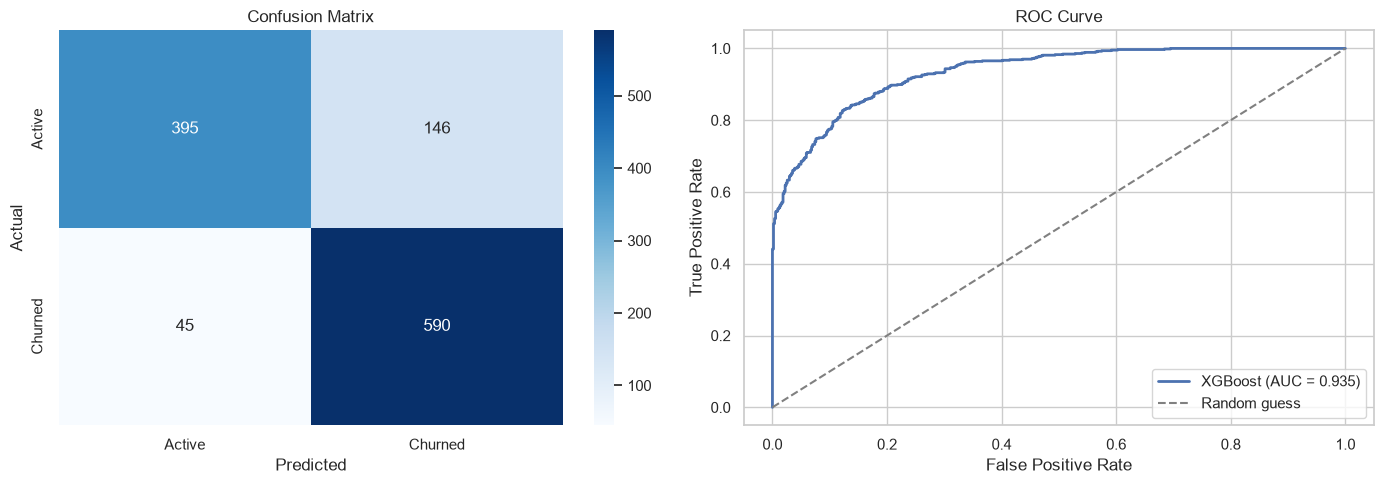

In [5]:
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"], yticklabels=["Active", "Churned"],
            ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/final_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## What Drives Churn Risk?

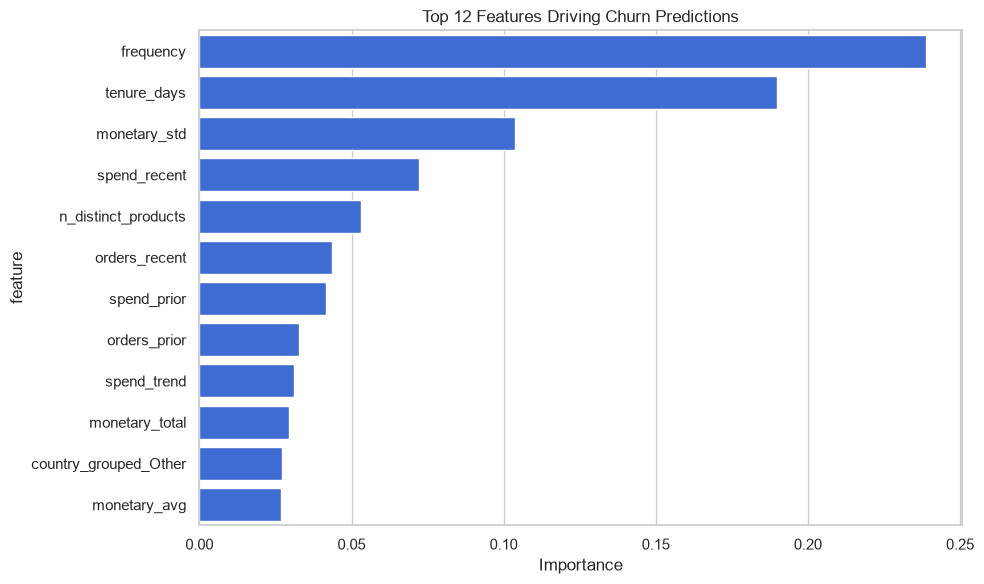

In [6]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#2563eb")
plt.title("Top 12 Features Driving Churn Predictions")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Key drivers:**
- **Purchase frequency** is the strongest predictor — customers with more total
  orders are meaningfully less likely to churn.
- **Tenure** shows a counterintuitive pattern: longer-tenured customers show
  *higher* churn risk, but this largely reflects long-registered accounts with
  sparse purchase history (a "long tenure, low engagement" dormant pattern),
  not that loyalty itself increases risk.
- **Spend variability** (`monetary_std`) and **recent vs. historical order
  activity** also contribute meaningfully, capturing behavioral trends beyond
  a static snapshot.

## Business Impact: Model-Targeted vs. Blanket Campaign

We compare two retention strategies:
- **Model-Targeted**: only contact customers the model flags as at-risk
- **Blanket**: contact every customer, regardless of predicted risk

Both strategies assume the same campaign cost and success rate; only the
*targeting* differs.

In [7]:
from src.config import RETENTION_CAMPAIGN_COST_PER_CUSTOMER, RETENTION_CAMPAIGN_SUCCESS_RATE

test_df = df.loc[X_test.index].copy()
test_df["predicted_churn"] = y_pred

avg_order_value = df["monetary_avg"].mean()

targeted = test_df[test_df["predicted_churn"] == 1]
actual_churners_targeted = targeted[targeted["is_churned"] == 1]

n_targeted = len(targeted)
revenue_targeted = len(actual_churners_targeted) * RETENTION_CAMPAIGN_SUCCESS_RATE * avg_order_value
cost_targeted = n_targeted * RETENTION_CAMPAIGN_COST_PER_CUSTOMER
net_targeted = revenue_targeted - cost_targeted

n_total = len(test_df)
n_actual_churners = test_df["is_churned"].sum()
revenue_blanket = n_actual_churners * RETENTION_CAMPAIGN_SUCCESS_RATE * avg_order_value
cost_blanket = n_total * RETENTION_CAMPAIGN_COST_PER_CUSTOMER
net_blanket = revenue_blanket - cost_blanket

summary = pd.DataFrame([
    {"Strategy": "Model-Targeted", "Customers Contacted": n_targeted,
     "Cost": cost_targeted, "Revenue Recovered": revenue_targeted, "Net Value": net_targeted},
    {"Strategy": "Blanket", "Customers Contacted": n_total,
     "Cost": cost_blanket, "Revenue Recovered": revenue_blanket, "Net Value": net_blanket},
])
summary

,Strategy,Customers Contacted,Cost,Revenue Recovered,Net Value
0,Model-Targeted,736,2208.0,34667.798598,32459.798598
1,Blanket,1176,3528.0,37311.952729,33783.952729


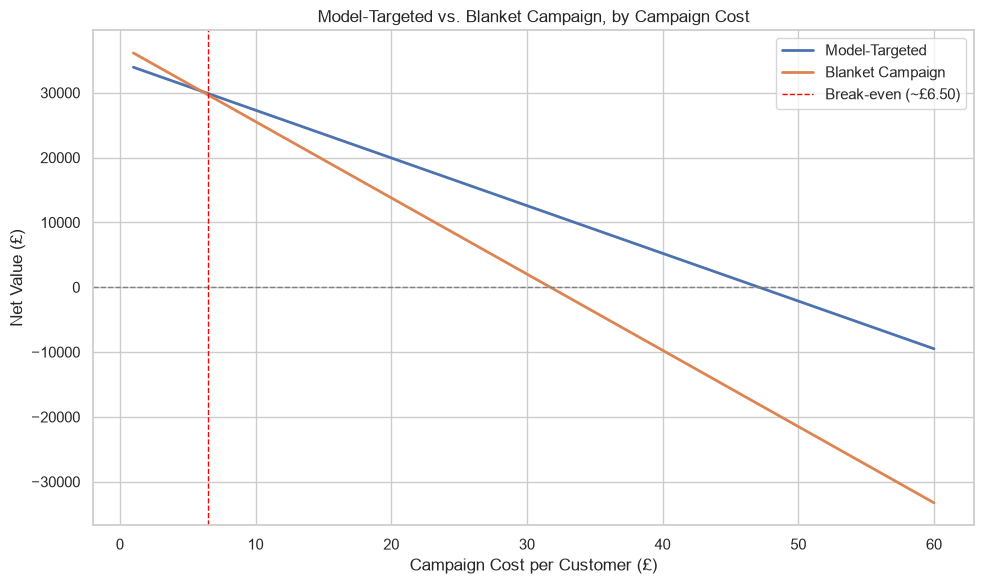

In [8]:
costs = list(range(1, 61))
model_values, blanket_values = [], []
for c in costs:
    mv = (len(actual_churners_targeted) * RETENTION_CAMPAIGN_SUCCESS_RATE * avg_order_value) - (n_targeted * c)
    bv = (n_actual_churners * RETENTION_CAMPAIGN_SUCCESS_RATE * avg_order_value) - (n_total * c)
    model_values.append(mv)
    blanket_values.append(bv)

plt.figure(figsize=(10, 6))
plt.plot(costs, model_values, label="Model-Targeted", linewidth=2)
plt.plot(costs, blanket_values, label="Blanket Campaign", linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(6.5, color="red", linestyle="--", linewidth=1, label="Break-even (~£6.50)")
plt.xlabel("Campaign Cost per Customer (£)")
plt.ylabel("Net Value (£)")
plt.title("Model-Targeted vs. Blanket Campaign, by Campaign Cost")
plt.legend()
plt.tight_layout()
plt.show()

## Limitations & Caveats

- **Campaign cost and success rate are assumptions, not observed data.**
  This dataset has no actual retention campaign history — the £3 cost and 15%
  success rate are reasonable placeholder assumptions, documented explicitly
  in `src/config.py`. Real deployment would require A/B testing to calibrate
  these numbers, and the break-even point (~£6.50) would shift accordingly.

- **The `tenure_days` feature has a structural relationship with the churn
  label.** Since `tenure_days ≥ recency_days` by definition, and churn requires
  `recency_days > 75`, churned customers necessarily have `tenure_days > 75`
  too. Part of `tenure_days`'s predictive power reflects this constraint, not
  purely behavioral insight — this is discussed in `04_modeling.ipynb`.

- **Single dataset, single time period.** Results reflect one UK-based
  gift/wholesale retailer over ~2 years (2009–2011). Churn drivers and the
  optimal campaign-cost threshold would likely differ for other industries,
  customer bases, or time periods (e.g., post-pandemic e-commerce behavior).

- **No holdout validation across time.** The train/test split is random, not
  time-based — meaning the model has implicitly seen some patterns from
  across the full date range during training, rather than being tested purely
  on "future" data relative to training. A true production deployment should
  validate on a strict time-based split (train on earlier customers, test on
  later ones) to better estimate real-world performance.

- **One-time buyers are harder to model.** ~28% of customers only ever placed
  one order — for this group, the model has limited behavioral history to
  learn from, and predictions for brand-new customers should be treated with
  lower confidence.

## Summary

- Built a churn prediction model (XGBoost, AUC 0.935) on real e-commerce
  transaction data, using an empirically-derived 75-day churn definition
  rather than an arbitrary threshold.
- Identified and corrected a data leakage issue during development
  (see `04_modeling.ipynb`) — an early version of the trend features
  unintentionally encoded the churn label itself, producing an
  unrealistic 0.98 AUC.
- Found that model-based targeting only outperforms a simple blanket
  campaign once the cost of contacting a customer exceeds ~£6.50 — a
  finding with direct, actionable implications for how the business
  should structure its retention campaigns by cost tier.
- Delivered results via an interactive Streamlit dashboard, allowing
  non-technical stakeholders to explore customer risk scores and simulate
  ROI under different cost/success-rate assumptions.